Orientacion original: ('P', 'S', 'L')
Dimensiones: 125 x 147 x 128
Eje seleccionado: 2
Corte automático seleccionado: 83
Score: 4262487.334371673


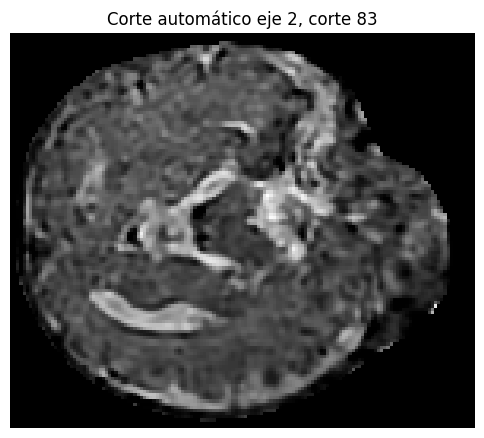


---- TAMANO DE MATRIZ ----
Dimensiones del volumen   : 125 x 147 x 128
Corte seleccionado        : 125 x 147 pixeles

---- RESOLUCION ESPACIAL ----
En X: 0.7500 mm/pixel
En Y: 0.7500 mm/pixel
En Z: 0.7500 mm/pixel
La resolucion espacial se obtiene de los metadatos del archivo NIfTI

---- RESOLUCION DE INTENSIDAD ----
Tipo de dato original: float64
Bits por pixel: 64 bits
A mayor cantidad de bits, mayor detalle en las diferencias de intensidad

---- ANALISIS DEL HISTOGRAMA ORIGINAL ----
Total de pixeles: 18375
Intensidad minima presente: 0
Intensidad maxima presente: 160
Intensidad mas frecuente (moda): 0
Pixeles en zona oscura  (0-127): 99.4%
Pixeles en zona brillante (128-255): 0.6%

---- RESULTADO DE LA ECUALIZACION ----
Rango dinamico antes de ecualizar: 160 niveles
Rango dinamico despues de ecualizar: 170 niveles

---- EVALUACION CUANTITATIVA DE FILTROS ----
Imagen             Contraste     Bordes      Ruido      Score
--------------------------------------------------------------

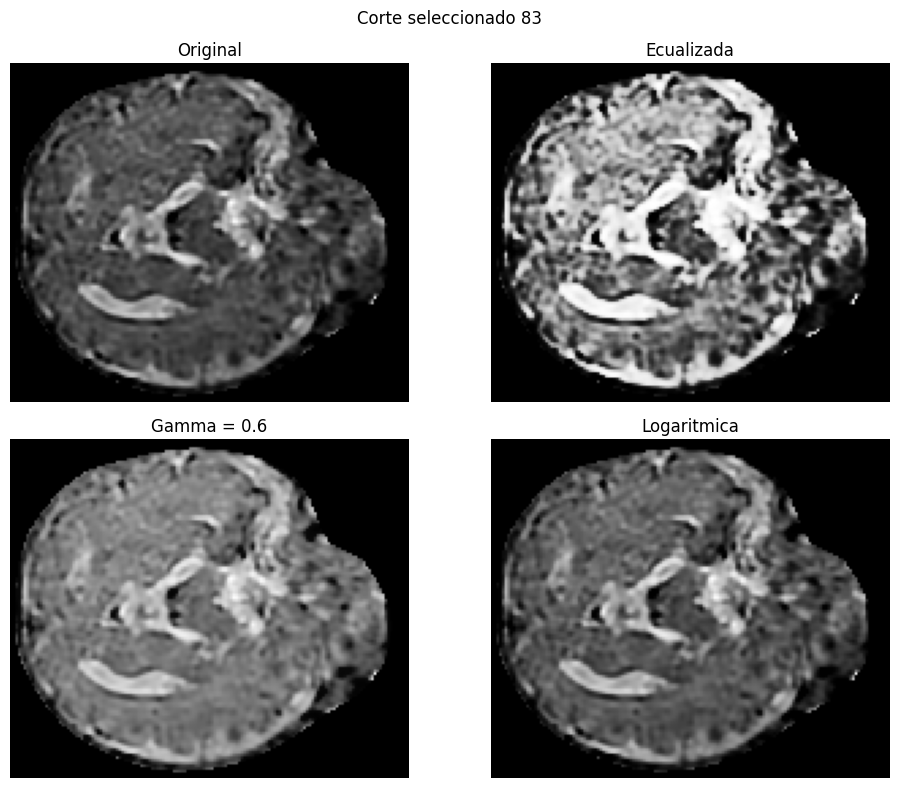

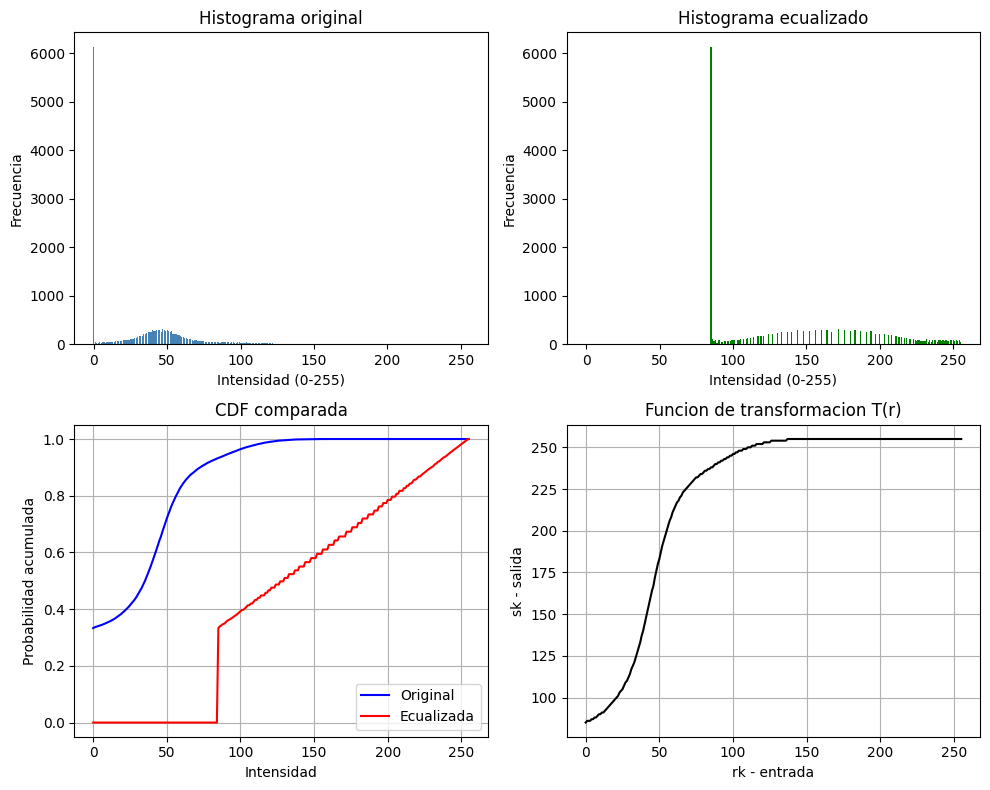


Resultado guardado en resultado_etapa1.npy


In [17]:
# ─────────────────────────────────────────────────────────
#  ETAPA I - Análisis digital de MRI fetal
#  Objetivo:
#  1. Cargar un volumen MRI fetal en formato NIfTI.
#  2. Normalizar las intensidades.
#  3. Seleccionar automáticamente el corte donde se observan mejor
#     estructuras brillantes compatibles con LCR/ventrículos.
#  4. Evaluar diferentes transformaciones de intensidad.
#  5. Guardar la imagen seleccionada para continuar con la Etapa II.
# ─────────────────────────────────────────────────────────

# Librería para leer archivos médicos en formato NIfTI (.nii)
import nibabel as nib

# Librería para operaciones numéricas y manejo de matrices
import numpy as np

# Librería para visualizar imágenes, histogramas y gráficas
import matplotlib.pyplot as plt

# Filtro de Sobel: permite estimar la cantidad de bordes de una imagen
from skimage.filters import sobel

# Filtro promedio: se usa para estimar ruido comparando imagen original vs suavizada
from scipy.ndimage import uniform_filter


# ── CAMBIA SOLO ESTA LÍNEA PARA CAMBIAR DE IMAGEN ──
# Ruta del archivo MRI fetal en formato NIfTI.
# Si quieres analizar otro caso, solo cambia esta ruta.
filename = r'C:\Users\meime\OneDrive\Documents\Procesamiento imagen\Reto\5187149.nii'


# ─────────────────────────────────────────────────────────
#  1. LEER Y NORMALIZAR
# ─────────────────────────────────────────────────────────

# Cargar el archivo NIfTI usando nibabel.
# img_nib contiene la imagen, metadatos, orientación y resolución espacial.
img_nib = nib.load(filename)

# Extraer los datos de intensidad del volumen MRI como arreglo NumPy.
# img_data normalmente es una matriz 3D: filas x columnas x cortes.
img_data = img_nib.get_fdata()

# Guardar el encabezado del archivo.
# Aquí vienen metadatos como voxel size, tipo de dato y bits por pixel.
info = img_nib.header

# Obtener la orientación anatómica original del volumen.
# Esto indica cómo están orientados los ejes del NIfTI.
orientacion = nib.aff2axcodes(img_nib.affine)
print(f'Orientacion original: {orientacion}')

# Convertir la imagen a tipo float para poder hacer operaciones matemáticas.
# Esto evita errores al normalizar o aplicar transformaciones.
img = img_data.astype(float)

# Algunos archivos NIfTI pueden venir en 4D.
# Por ejemplo: filas x columnas x cortes x tiempo/volumen.
# Si es 4D, se toma únicamente el primer volumen.
if img.ndim == 4:
    img = img[:, :, :, 0]

# Normalizar intensidades entre 0 y 1.
# Esto facilita comparar imágenes y aplicar filtros sin depender del rango original.
img = img / img.max()

# Obtener dimensiones del volumen:
# filas = tamaño en eje X
# cols = tamaño en eje Y
# num_cortes = número de cortes disponibles
filas, cols, num_cortes = img.shape
print(f'Dimensiones: {filas} x {cols} x {num_cortes}')


# ─────────────────────────────────────────────────────────
#  2. SELECCIÓN AUTOMÁTICA DEL CORTE
# ─────────────────────────────────────────────────────────

# Esta función asigna un puntaje a cada corte.
# La idea es buscar cortes con zonas brillantes centrales, ya que en MRI fetal
# el LCR suele verse brillante y puede ayudar a localizar los ventrículos.
def score_corte(corte):

    # Si el corte está completamente vacío, no sirve.
    # Se le asigna score 0.
    if np.max(corte) == 0:
        return 0

    # Normalizar el corte entre 0 y 1 para comparar intensidades.
    corte_norm = corte / np.max(corte)

    # Obtener tamaño del corte 2D.
    alto, ancho = corte_norm.shape

    # Crear una máscara simple para quitar el fondo.
    # Los píxeles con intensidad mayor a 0.05 se consideran parte de la imagen.
    mascara = corte_norm > 0.05

    # Calcular cuántos píxeles pertenecen a esa máscara.
    area = np.sum(mascara)

    # Si el área es muy pequeña, probablemente el corte no contiene cerebro útil.
    # Por eso se descarta con score 0.
    if area < 200:
        return 0

    # Definir una región central amplia del corte.
    # Se toma del 25% al 75% en ambas direcciones.
    # Esto evita que el algoritmo se enfoque demasiado en estructuras periféricas.
    y1 = int(alto * 0.25)
    y2 = int(alto * 0.75)
    x1 = int(ancho * 0.25)
    x2 = int(ancho * 0.75)

    # Extraer esa región central.
    centro = corte_norm[y1:y2, x1:x2]

    # Tomar solamente los píxeles que pertenecen a la imagen, no al fondo.
    pixeles_validos = corte_norm[mascara]

    # Calcular un umbral alto de brillo.
    # El percentil 95 conserva solo los píxeles más brillantes.
    umbral_brillante = np.percentile(pixeles_validos, 95)

    # Contar cuántos píxeles brillantes hay dentro de la zona central.
    # Estos píxeles podrían corresponder a LCR o estructuras ventriculares.
    brillantes_centrales = np.sum(centro > umbral_brillante)

    # Contar cuántos píxeles brillantes hay en todo el corte.
    brillo_total = np.sum(corte_norm > umbral_brillante)

    # Calcular qué proporción del brillo total está en la zona central.
    # Si hay mucho brillo periférico, esta proporción baja.
    proporcion_central = brillantes_centrales / (brillo_total + 1e-8)

    # Score final:
    # - aumenta si hay muchos píxeles brillantes centrales
    # - aumenta si el brillo está concentrado en el centro
    # - aumenta si el corte tiene suficiente área anatómica
    score = brillantes_centrales * proporcion_central * area

    return score


# Inicializar variables para guardar el mejor corte encontrado.
mejor_score = -1
mejor_corte = None
mejor_eje = None
A = None

# Probar los tres ejes del volumen:
# eje 0 → cortes img[k, :, :]
# eje 1 → cortes img[:, k, :]
# eje 2 → cortes img[:, :, k]
for eje in range(3):

    # Número de cortes disponibles en ese eje.
    n_cortes = img.shape[eje]

    # Se evita analizar los extremos del volumen porque suelen tener poca información.
    # Se analiza del 35% al 70% de los cortes.
    inicio = int(n_cortes * 0.35)
    fin = int(n_cortes * 0.70)

    # Recorrer los cortes dentro del rango definido.
    for k in range(inicio, fin):

        # Extraer el corte 2D dependiendo del eje que se está evaluando.
        if eje == 0:
            corte = img[k, :, :]
        elif eje == 1:
            corte = img[:, k, :]
        else:
            corte = img[:, :, k]

        # Calcular el score de ese corte.
        s = score_corte(corte)

        # Si este corte tiene mejor score que los anteriores,
        # se guarda como el mejor corte hasta el momento.
        if s > mejor_score:
            mejor_score = s
            mejor_corte = k
            mejor_eje = eje
            A = corte

# Guardar dimensiones del corte seleccionado.
filas_corte, cols_corte = A.shape

# Guardar índice del corte seleccionado para usarlo después.
corte_seleccionado = mejor_corte

# Mostrar información del corte elegido.
print("Eje seleccionado:", mejor_eje)
print("Corte automático seleccionado:", mejor_corte)
print("Score:", mejor_score)

# Visualizar el corte elegido automáticamente.
plt.figure(figsize=(6,6))
plt.imshow(A, cmap='gray')
plt.title(f"Corte automático eje {mejor_eje}, corte {mejor_corte}")
plt.axis("off")
plt.show()


# ─────────────────────────────────────────────────────────
#  3. ANÁLISIS TÉCNICO DEL MUESTREO
# ─────────────────────────────────────────────────────────

# Obtener tamaño del voxel desde los metadatos.
# voxel_size indica cuántos mm representa cada pixel/voxel.
voxel_size = info.get_zooms()

# Obtener número de bits por pixel desde el encabezado.
bits = info['bitpix']

print('\n---- TAMANO DE MATRIZ ----')
print(f'Dimensiones del volumen   : {filas} x {cols} x {num_cortes}')
print(f'Corte seleccionado        : {filas_corte} x {cols_corte} pixeles')

print('\n---- RESOLUCION ESPACIAL ----')
print(f'En X: {voxel_size[0]:.4f} mm/pixel')
print(f'En Y: {voxel_size[1]:.4f} mm/pixel')
print(f'En Z: {voxel_size[2]:.4f} mm/pixel')
print('La resolucion espacial se obtiene de los metadatos del archivo NIfTI')

print('\n---- RESOLUCION DE INTENSIDAD ----')
print(f'Tipo de dato original: {img_data.dtype}')
print(f'Bits por pixel: {bits} bits')
print('A mayor cantidad de bits, mayor detalle en las diferencias de intensidad')


# ─────────────────────────────────────────────────────────
#  4. HISTOGRAMA ORIGINAL
# ─────────────────────────────────────────────────────────

# Definir número de niveles de gris.
# Se usa 256 porque la imagen se convierte a escala de 8 bits para el histograma.
L = 256

# Convertir la imagen normalizada [0,1] a valores enteros [0,255].
A256 = (A * (L - 1)).astype(np.uint8)

# Crear un histograma vacío con 256 posiciones.
hist_orig = np.zeros(L)

# Recorrer todos los píxeles del corte seleccionado.
for i in range(filas_corte):
    for j in range(cols_corte):

        # Aumentar en 1 el contador correspondiente a la intensidad del píxel.
        hist_orig[int(A256[i, j])] += 1

# Convertir el histograma a función de probabilidad.
# Cada valor indica la proporción de píxeles con esa intensidad.
pdf_orig = hist_orig / (filas_corte * cols_corte)

# Calcular la función de distribución acumulada.
# Sirve para la ecualización del histograma.
cdf_orig = np.cumsum(pdf_orig)

# Contar píxeles en la mitad oscura del histograma.
pixeles_bajos = np.sum(hist_orig[:128])

# Convertir esa cantidad a porcentaje.
porc_bajos = (pixeles_bajos / (filas_corte * cols_corte)) * 100

print('\n---- ANALISIS DEL HISTOGRAMA ORIGINAL ----')
print(f'Total de pixeles: {filas_corte * cols_corte}')
print(f'Intensidad minima presente: {np.argmax(hist_orig > 0)}')
print(f'Intensidad maxima presente: {L - 1 - np.argmax(hist_orig[::-1] > 0)}')
print(f'Intensidad mas frecuente (moda): {np.argmax(hist_orig)}')
print(f'Pixeles en zona oscura  (0-127): {porc_bajos:.1f}%')
print(f'Pixeles en zona brillante (128-255): {100 - porc_bajos:.1f}%')


# ─────────────────────────────────────────────────────────
#  5. ECUALIZACIÓN
# ─────────────────────────────────────────────────────────

# Crear función de transformación para ecualizar el histograma.
# La CDF se multiplica por 255 para mapear intensidades antiguas a nuevas.
T = np.round((L - 1) * cdf_orig).astype(np.uint8)

# Aplicar la transformación T a la imagen original.
# Cada píxel se reemplaza por su nueva intensidad ecualizada.
A_eq = T[A256].astype(float) / (L - 1)

# Crear histograma vacío para la imagen ecualizada.
hist_eq = np.zeros(L)

# Convertir imagen ecualizada a 8 bits.
A_eq256 = (A_eq * (L - 1)).astype(np.uint8)

# Calcular histograma de la imagen ecualizada.
for i in range(filas_corte):
    for j in range(cols_corte):
        hist_eq[int(A_eq256[i, j])] += 1

# PDF y CDF de la imagen ecualizada.
pdf_eq = hist_eq / (filas_corte * cols_corte)
cdf_eq = np.cumsum(pdf_eq)

# Calcular rango dinámico antes y después.
# El rango dinámico es la diferencia entre intensidad máxima y mínima presentes.
rango_orig = (L - 1 - np.argmax(hist_orig[::-1] > 0)) - np.argmax(hist_orig > 0)
rango_eq = (L - 1 - np.argmax(hist_eq[::-1] > 0)) - np.argmax(hist_eq > 0)

print('\n---- RESULTADO DE LA ECUALIZACION ----')
print(f'Rango dinamico antes de ecualizar: {rango_orig} niveles')
print(f'Rango dinamico despues de ecualizar: {rango_eq} niveles')


# ─────────────────────────────────────────────────────────
#  6. GAMMA Y LOGARÍTMICA
# ─────────────────────────────────────────────────────────

# Transformación gamma.
# Gamma menor a 1 aclara intensidades intermedias.
gamma = 0.6
A_gam = np.power(np.clip(A, 0, 1), gamma)

# Transformación logarítmica.
# Resalta intensidades bajas/intermedias y comprime intensidades altas.
c_log = 1 / np.log(1 + A.max())
A_log = c_log * np.log(1 + A)


# ─────────────────────────────────────────────────────────
#  7. EVALUACIÓN CUANTITATIVA
# ─────────────────────────────────────────────────────────

# Umbral para separar píxeles brillantes y oscuros al calcular contraste.
umbral_eval = 0.7

# Lista de imágenes a comparar.
imagenes = [A, A_eq, A_gam, A_log]

# Nombres de las imágenes evaluadas.
nombres = ['Original', 'Ecualizada', 'Gamma 0.6', 'Logaritmica']

print('\n---- EVALUACION CUANTITATIVA DE FILTROS ----')
print(f'{"Imagen":<15} {"Contraste":>12} {"Bordes":>10} {"Ruido":>10} {"Score":>10}')
print('-'*70)

# Vector para guardar el score de cada imagen.
scores = np.zeros(4)

# Evaluar cada versión de la imagen.
for n in range(4):

    # Seleccionar imagen actual.
    Im = imagenes[n]

    # Separar píxeles brillantes y oscuros.
    pixeles_brill = Im[Im > umbral_eval]
    pixeles_osc = Im[Im <= umbral_eval]

    # Calcular intensidad media de los píxeles brillantes.
    media_brill = np.mean(pixeles_brill) if len(pixeles_brill) > 0 else 0

    # Calcular intensidad media de los píxeles oscuros.
    media_osc = np.mean(pixeles_osc) if len(pixeles_osc) > 0 else 0

    # Contraste: diferencia entre zonas brillantes y oscuras.
    contraste = media_brill - media_osc

    # Bordes: promedio del filtro Sobel.
    # Un valor mayor indica más presencia de bordes anatómicos.
    bordes = np.mean(sobel(Im))

    # Crear una versión suavizada de la imagen.
    suavizada = uniform_filter(Im, size=3)

    # Estimar ruido como diferencia entre imagen original y suavizada.
    ruido = np.std(Im - suavizada)

    # Score final:
    # Premia alto contraste y bordes, pero penaliza ruido.
    scores[n] = (contraste * bordes) / (ruido + 1e-8)

    # Imprimir métricas de esa imagen.
    print(f'{nombres[n]:<15} {contraste:>12.4f} {bordes:>10.4f} {ruido:>10.4f} {scores[n]:>10.4f}')

# Seleccionar la imagen con mayor score.
idx_mejor = np.argmax(scores)

print('\n---- JUSTIFICACION DE IMAGEN SELECCIONADA PARA ETAPA II ----')
print(f'Se selecciona la imagen {nombres[idx_mejor].upper()} para continuar a Etapa II\n')

# Mostrar todos los scores para justificar la elección.
for i in range(4):
    print(f'  - {nombres[i]:<12} Score: {scores[i]:.4f}')

print(f'\nLa imagen {nombres[idx_mejor]} obtuvo el mayor score,')
print('ya que presenta el mejor equilibrio entre contraste,')
print('preservacion de bordes y reduccion del ruido,')
print('facilitando la segmentacion de las estructuras ventriculares.')


# ─────────────────────────────────────────────────────────
#  8. FIGURAS
# ─────────────────────────────────────────────────────────

# Mostrar comparación visual entre las transformaciones.
fig, axs = plt.subplots(2, 2, figsize=(10, 8))

axs[0,0].imshow(A, cmap='gray')
axs[0,0].set_title('Original')
axs[0,0].axis('off')

axs[0,1].imshow(A_eq, cmap='gray')
axs[0,1].set_title('Ecualizada')
axs[0,1].axis('off')

axs[1,0].imshow(A_gam, cmap='gray')
axs[1,0].set_title('Gamma = 0.6')
axs[1,0].axis('off')

axs[1,1].imshow(A_log, cmap='gray')
axs[1,1].set_title('Logaritmica')
axs[1,1].axis('off')

plt.suptitle(f'Corte seleccionado {corte_seleccionado}')
plt.tight_layout()


# Crear eje de intensidades de 0 a 255.
rk = np.arange(L)

# Mostrar histogramas y funciones acumuladas.
fig, axs = plt.subplots(2, 2, figsize=(10, 8))

axs[0,0].bar(rk, hist_orig, color='steelblue')
axs[0,0].set_title('Histograma original')
axs[0,0].set_xlabel('Intensidad (0-255)')
axs[0,0].set_ylabel('Frecuencia')

axs[0,1].bar(rk, hist_eq, color='green')
axs[0,1].set_title('Histograma ecualizado')
axs[0,1].set_xlabel('Intensidad (0-255)')
axs[0,1].set_ylabel('Frecuencia')

axs[1,0].plot(rk, cdf_orig, 'b', label='Original')
axs[1,0].plot(rk, cdf_eq, 'r', label='Ecualizada')
axs[1,0].set_title('CDF comparada')
axs[1,0].set_xlabel('Intensidad')
axs[1,0].set_ylabel('Probabilidad acumulada')
axs[1,0].legend()
axs[1,0].grid(True)

axs[1,1].plot(rk, T, 'k')
axs[1,1].set_title('Funcion de transformacion T(r)')
axs[1,1].set_xlabel('rk - entrada')
axs[1,1].set_ylabel('sk - salida')
axs[1,1].grid(True)

plt.tight_layout()
plt.show()


# ─────────────────────────────────────────────────────────
#  9. GUARDAR PARA ETAPA II
# ─────────────────────────────────────────────────────────

# Se selecciona la imagen logarítmica para continuar.
# Esta decisión está alineada con el pipeline actual del proyecto.
A_sel = np.clip(np.real(A_log), 0, 1)

# Guardar datos relevantes para las siguientes etapas.
# A_sel será la imagen que se procesará en Etapa II.
np.save('resultado_etapa1.npy', {
    'A_sel': A_sel,
    'voxel_size': np.array(voxel_size),
    'filas': filas_corte,
    'cols': cols_corte,
    'pdf_orig': pdf_orig
})

print('\nResultado guardado en resultado_etapa1.npy')


---- TIPO DE RUIDO ----
Ruido predominante: Gaussiano
En MRI el ruido es causado por fluctuaciones termicas del equipo
Se manifiesta como granulado suave sobre toda la imagen
Se descarta sal y pimienta porque no hay puntos aislados

---- MSE DE CADA FILTRO ----
MSE medias filtropro    : 0.001692
MSE gaussiano filtropro : 0.001258
MSE gaussiano scipy     : 0.002075
MSE mediana scipy       : 0.000997
MSE filtroU (k=1)       : 0.001035
Un MSE menor indica que el filtro distorsiona menos la imagen

---- PIXELES BRILLANTES SEGMENTADOS (umbral 0.5) ----
Original (referencia) : 2054
Medias filtropro      : 1719  (83.7% respecto original)
Gaussiano filtropro   : 1702   (82.9% respecto original)
Gaussiano scipy       : 1661  (80.9% respecto original)
Mediana scipy         : 1836     (89.4% respecto original)
filtroU (k=1)         : 2404       (117.0% respecto original)

---- FILTRO SELECCIONADO PARA ETAPA III ----
Se selecciona el filtro MEDIANA
Justificacion cuantitativa:
  - MSE mas bajo: 0.

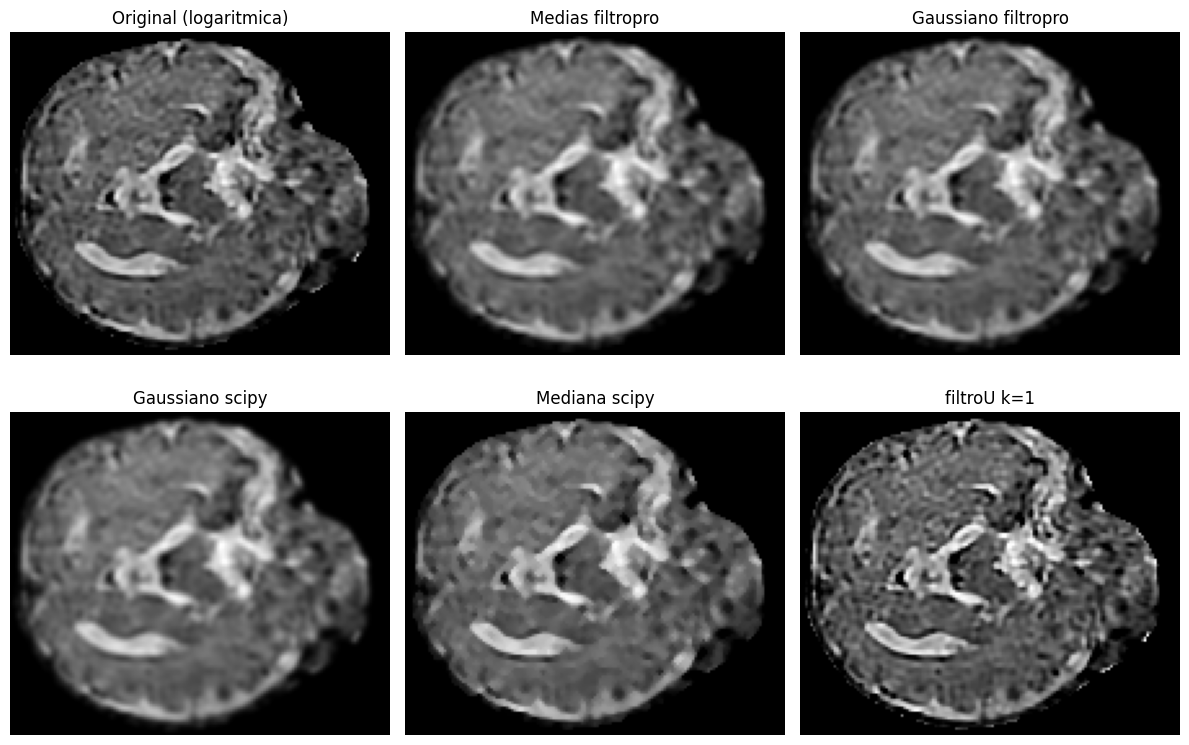

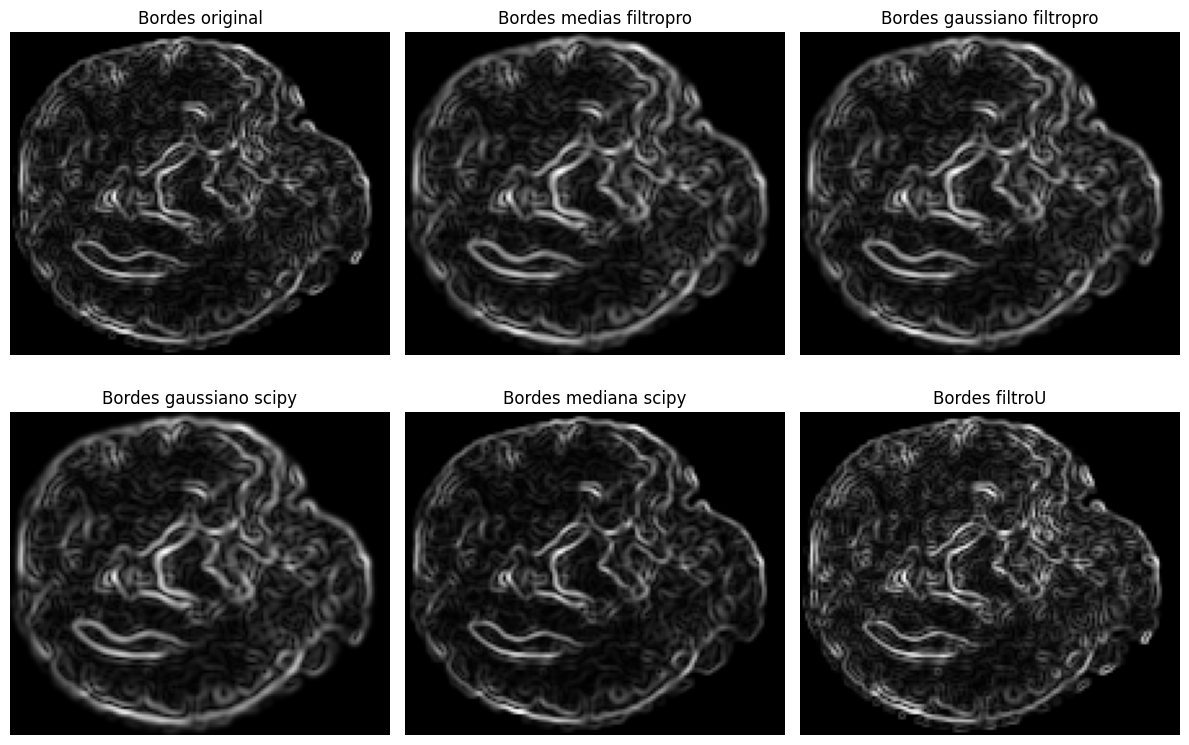


Resultado guardado en resultado_etapa2.npy


In [18]:
# ─────────────────────────────────────────────────────────
#  ETAPA II - Preprocesamiento y reducción de ruido
#  Objetivo:
#  1. Cargar la imagen seleccionada en la Etapa I.
#  2. Aplicar distintos filtros de suavizado y realce.
#  3. Comparar cuantitativamente qué filtro altera menos la imagen.
#  4. Evaluar conservación de píxeles brillantes y bordes.
#  5. Seleccionar el filtro más adecuado para continuar con la segmentación.
#
#  Requiere:
#  - funcionespro.py en la misma carpeta.
#  - resultado_etapa1.npy generado previamente.
# ─────────────────────────────────────────────────────────

# Librería para operaciones numéricas con matrices.
import numpy as np

# Librería para mostrar imágenes y gráficas.
import matplotlib.pyplot as plt

# median_filter: filtro de mediana para reducir ruido preservando bordes.
# gaussian_filter: filtro gaussiano para suavizar la imagen.
from scipy.ndimage import median_filter, gaussian_filter

# threshold_otsu se importa por si se requiere umbralización automática.
# En este bloque no se utiliza directamente, pero puede servir para pruebas.
from skimage.filters import threshold_otsu

# Importar funciones personalizadas del archivo funcionespro.py.
# filtropro contiene filtros implementados manualmente.
# filtroU corresponde al filtro de realce tipo unsharp masking.
from funcionespro import filtropro, filtroU


# ─────────────────────────────────────────────────────────
#  CARGAR RESULTADO DE ETAPA I
# ─────────────────────────────────────────────────────────

# Cargar el archivo generado en la Etapa I.
# allow_pickle=True permite leer el diccionario guardado con np.save.
datos = np.load('resultado_etapa1.npy', allow_pickle=True).item()

# Imagen seleccionada en Etapa I.
# Normalmente corresponde a la imagen transformada logarítmicamente.
A_sel = datos['A_sel']

# Tamaño del voxel en mm, obtenido desde los metadatos del archivo NIfTI.
voxel_size = datos['voxel_size']

# Número de filas de la imagen seleccionada.
filas = datos['filas']

# Número de columnas de la imagen seleccionada.
cols = datos['cols']


# ─────────────────────────────────────────────────────────
#  IDENTIFICACIÓN DEL TIPO DE RUIDO
# ─────────────────────────────────────────────────────────

# Imprimir una interpretación cualitativa del ruido esperado en MRI.
# En resonancia magnética suele observarse ruido tipo gaussiano o Rician,
# pero para este proyecto se simplifica como ruido gaussiano.
print('\n---- TIPO DE RUIDO ----')
print('Ruido predominante: Gaussiano')
print('En MRI el ruido es causado por fluctuaciones termicas del equipo')
print('Se manifiesta como granulado suave sobre toda la imagen')
print('Se descarta sal y pimienta porque no hay puntos aislados')


# ─────────────────────────────────────────────────────────
#  APLICAR FILTROS
# ─────────────────────────────────────────────────────────

# Aplicar filtro de medias usando la función personalizada filtropro.
# Este filtro promedia los vecinos del píxel, suavizando ruido,
# pero puede difuminar bordes anatómicos.
A_medias = filtropro(A_sel, 1)

# Aplicar filtro gaussiano usando filtropro.
# También suaviza ruido, pero pondera más los píxeles cercanos al centro.
A_gauss = filtropro(A_sel, 2)

# Aplicar filtro gaussiano usando scipy.
# sigma=1 controla el grado de suavizado.
# Se usa como comparación con el filtro gaussiano implementado manualmente.
A_gauss_m = gaussian_filter(A_sel, sigma=1)

# Aplicar filtro de mediana con una ventana de 3x3.
# Este filtro reemplaza cada píxel por la mediana de sus vecinos.
# Es útil para reducir ruido sin perder tanto los bordes.
A_med = median_filter(A_sel, size=3)

# Aplicar filtro de realce tipo unsharp masking.
# Este filtro enfatiza bordes y detalles.
A_U = filtroU(A_sel, 1)


# Recortar todas las imágenes al rango [0, 1].
# Esto evita valores negativos o mayores a 1 después de aplicar filtros.
A_medias  = np.clip(A_medias,  0, 1)
A_gauss   = np.clip(A_gauss,   0, 1)
A_gauss_m = np.clip(A_gauss_m, 0, 1)
A_med     = np.clip(A_med,     0, 1)
A_U       = np.clip(A_U,       0, 1)


# ─────────────────────────────────────────────────────────
#  MSE DE CADA FILTRO
# ─────────────────────────────────────────────────────────

# Calcular el error cuadrático medio entre la imagen original seleccionada
# y cada imagen filtrada.
# El MSE mide cuánto cambió la imagen después del filtrado.
# Un valor menor significa menor distorsión respecto a la imagen de entrada.
mse_medias  = np.mean((A_sel - A_medias) ** 2)
mse_gauss   = np.mean((A_sel - A_gauss)  ** 2)
mse_gauss_m = np.mean((A_sel - A_gauss_m)** 2)
mse_med     = np.mean((A_sel - A_med)    ** 2)
mse_U       = np.mean((A_sel - A_U)      ** 2)

# Mostrar los MSE obtenidos.
print('\n---- MSE DE CADA FILTRO ----')
print(f'MSE medias filtropro    : {mse_medias:.6f}')
print(f'MSE gaussiano filtropro : {mse_gauss:.6f}')
print(f'MSE gaussiano scipy     : {mse_gauss_m:.6f}')
print(f'MSE mediana scipy       : {mse_med:.6f}')
print(f'MSE filtroU (k=1)       : {mse_U:.6f}')
print('Un MSE menor indica que el filtro distorsiona menos la imagen')


# ─────────────────────────────────────────────────────────
#  PÍXELES SEGMENTADOS POR CADA FILTRO
# ─────────────────────────────────────────────────────────

# Definir un umbral fijo para contar píxeles brillantes.
# En este caso, todo píxel mayor a 0.5 se considera brillante.
umbral = 0.5

# Contar cuántos píxeles brillantes tiene cada imagen.
# Esto ayuda a verificar si un filtro elimina estructuras brillantes importantes.
px_orig   = np.sum(A_sel > umbral)
px_medias = np.sum(A_medias > umbral)
px_gauss  = np.sum(A_gauss > umbral)
px_gaussm = np.sum(A_gauss_m > umbral)
px_med    = np.sum(A_med > umbral)
px_U      = np.sum(A_U > umbral)

# Mostrar el número de píxeles brillantes y su porcentaje respecto a la original.
print('\n---- PIXELES BRILLANTES SEGMENTADOS (umbral 0.5) ----')
print(f'Original (referencia) : {px_orig}')
print(f'Medias filtropro      : {px_medias}  ({px_medias/px_orig*100:.1f}% respecto original)')
print(f'Gaussiano filtropro   : {px_gauss}   ({px_gauss/px_orig*100:.1f}% respecto original)')
print(f'Gaussiano scipy       : {px_gaussm}  ({px_gaussm/px_orig*100:.1f}% respecto original)')
print(f'Mediana scipy         : {px_med}     ({px_med/px_orig*100:.1f}% respecto original)')
print(f'filtroU (k=1)         : {px_U}       ({px_U/px_orig*100:.1f}% respecto original)')


# ─────────────────────────────────────────────────────────
#  BORDES CON SOBEL
# ─────────────────────────────────────────────────────────

# Función para calcular bordes de una imagen usando filtros tipo Sobel.
# filtropro(img, 5) calcula gradiente horizontal.
# filtropro(img, 6) calcula gradiente vertical.
def calcular_bordes(img):

    # Gradiente en dirección X.
    bx = filtropro(img, 5)

    # Gradiente en dirección Y.
    by = filtropro(img, 6)

    # Magnitud del gradiente.
    # Combina bordes horizontales y verticales.
    bordes = np.sqrt(bx**2 + by**2)

    # Normalizar el mapa de bordes entre 0 y 1.
    return bordes / bordes.max()


# Calcular mapas de borde para cada imagen.
bordes_orig   = calcular_bordes(A_sel)
bordes_medias = calcular_bordes(A_medias)
bordes_gauss  = calcular_bordes(A_gauss)
bordes_gaussm = calcular_bordes(A_gauss_m)
bordes_med    = calcular_bordes(A_med)
bordes_U      = calcular_bordes(A_U)


# ─────────────────────────────────────────────────────────
#  JUSTIFICACIÓN DEL FILTRO SELECCIONADO
# ─────────────────────────────────────────────────────────

# Se selecciona el filtro de mediana como imagen de salida.
# La justificación combina:
# - bajo MSE,
# - conservación de píxeles brillantes,
# - preservación de bordes,
# - menor exageración que el filtro unsharp.
print('\n---- FILTRO SELECCIONADO PARA ETAPA III ----')
print('Se selecciona el filtro MEDIANA')
print('Justificacion cuantitativa:')
print(f'  - MSE mas bajo: {mse_med:.6f}, distorsiona menos la imagen')
print(f'  - Conserva {px_med/px_orig*100:.1f}% de los pixeles brillantes respecto a la original')
print('  - Mejor balance entre reduccion de ruido y preservacion del ventriculo')
print('  - El filtroU detecta mas pixeles pero exagera bordes')
print('  - Los gaussianos pierden mas pixeles al suavizar')


# ─────────────────────────────────────────────────────────
#  FIGURAS
# ─────────────────────────────────────────────────────────

# Figura 1:
# Comparación visual de la imagen original y las imágenes filtradas.
fig, axs = plt.subplots(2, 3, figsize=(12, 8))

axs[0,0].imshow(A_sel, cmap='gray')
axs[0,0].set_title('Original (logaritmica)')
axs[0,0].axis('off')

axs[0,1].imshow(A_medias, cmap='gray')
axs[0,1].set_title('Medias filtropro')
axs[0,1].axis('off')

axs[0,2].imshow(A_gauss, cmap='gray')
axs[0,2].set_title('Gaussiano filtropro')
axs[0,2].axis('off')

axs[1,0].imshow(A_gauss_m, cmap='gray')
axs[1,0].set_title('Gaussiano scipy')
axs[1,0].axis('off')

axs[1,1].imshow(A_med, cmap='gray')
axs[1,1].set_title('Mediana scipy')
axs[1,1].axis('off')

axs[1,2].imshow(A_U, cmap='gray')
axs[1,2].set_title('filtroU k=1')
axs[1,2].axis('off')

plt.tight_layout()


# Figura 2:
# Comparación de los bordes detectados en cada imagen.
# Esto permite observar si un filtro conserva, pierde o exagera los contornos.
fig, axs = plt.subplots(2, 3, figsize=(12, 8))

axs[0,0].imshow(bordes_orig, cmap='gray')
axs[0,0].set_title('Bordes original')
axs[0,0].axis('off')

axs[0,1].imshow(bordes_medias, cmap='gray')
axs[0,1].set_title('Bordes medias filtropro')
axs[0,1].axis('off')

axs[0,2].imshow(bordes_gauss, cmap='gray')
axs[0,2].set_title('Bordes gaussiano filtropro')
axs[0,2].axis('off')

axs[1,0].imshow(bordes_gaussm, cmap='gray')
axs[1,0].set_title('Bordes gaussiano scipy')
axs[1,0].axis('off')

axs[1,1].imshow(bordes_med, cmap='gray')
axs[1,1].set_title('Bordes mediana scipy')
axs[1,1].axis('off')

axs[1,2].imshow(bordes_U, cmap='gray')
axs[1,2].set_title('Bordes filtroU')
axs[1,2].axis('off')

plt.tight_layout()
plt.show()


# ─────────────────────────────────────────────────────────
#  GUARDAR PARA ETAPA III
# ─────────────────────────────────────────────────────────

# Se elige la imagen filtrada con mediana para continuar.
# Esta imagen será usada en Etapa III para segmentar LCR/ventrículos.
A_filt = np.clip(A_med, 0, 1)

# Guardar imagen filtrada y metadatos necesarios.
np.save('resultado_etapa2.npy', {
    'A_filt'    : A_filt,
    'voxel_size': voxel_size,
    'filas'     : filas,
    'cols'      : cols
})

print('\nResultado guardado en resultado_etapa2.npy')

C:\Users\meime\AppData\Local\Temp\ipykernel_12856\2324805997.py:75: FutureWarning: Parameter `min_size` is deprecated since version 0.26.0 and will be removed in 2.0.0 (or later). To avoid this warning, please use the parameter `max_size` instead. For more details, see the documentation of `remove_small_objects`. Note that the new threshold removes objects smaller than **or equal to** its value, while the previous parameter only removed smaller ones.
  mask_cerebro_limpia = remove_small_objects(mask_cerebro_limpia, min_size=500)


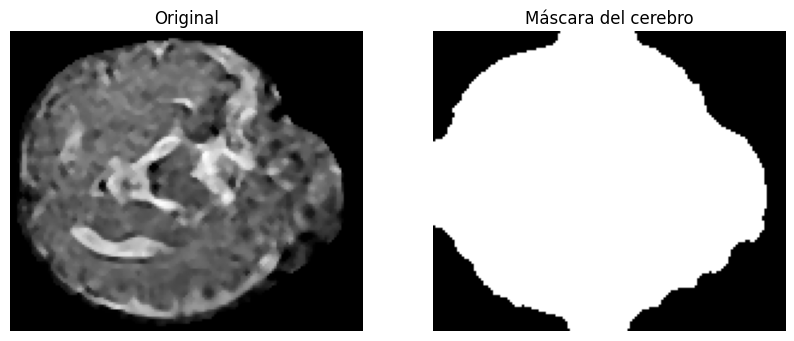

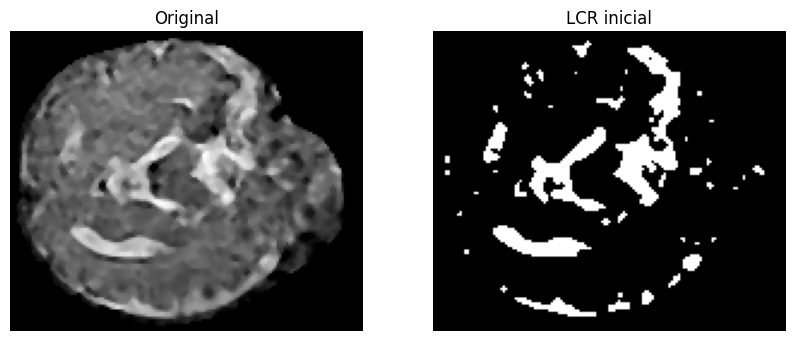

C:\Users\meime\AppData\Local\Temp\ipykernel_12856\2324805997.py:117: FutureWarning: Parameter `min_size` is deprecated since version 0.26.0 and will be removed in 2.0.0 (or later). To avoid this warning, please use the parameter `max_size` instead. For more details, see the documentation of `remove_small_objects`. Note that the new threshold removes objects smaller than **or equal to** its value, while the previous parameter only removed smaller ones.
  mask_lcr_limpia = remove_small_objects(mask_lcr_limpia, min_size=20)


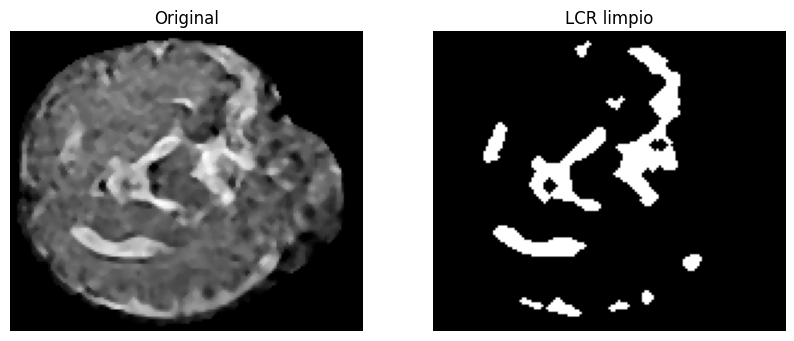

C:\Users\meime\AppData\Local\Temp\ipykernel_12856\2324805997.py:131: FutureWarning: `binary_erosion` is deprecated since version 0.26 and will be removed in version 0.28. Use `skimage.morphology.erosion` instead. Note the pixel shift by 1 for even-sized footprints (see docstring notes).
  mask_cerebro_interno = binary_erosion(mask_cerebro_limpia, disk(18))


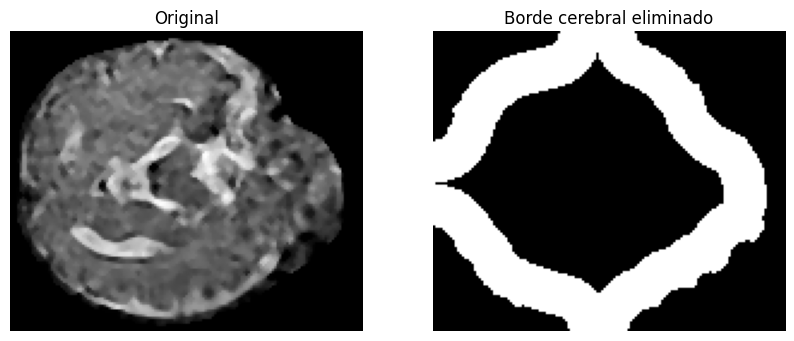

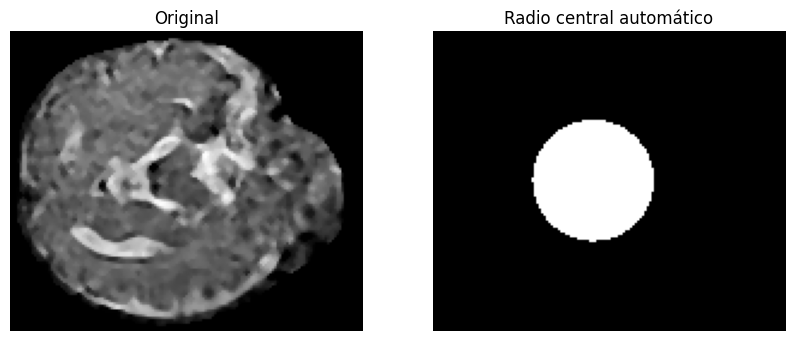

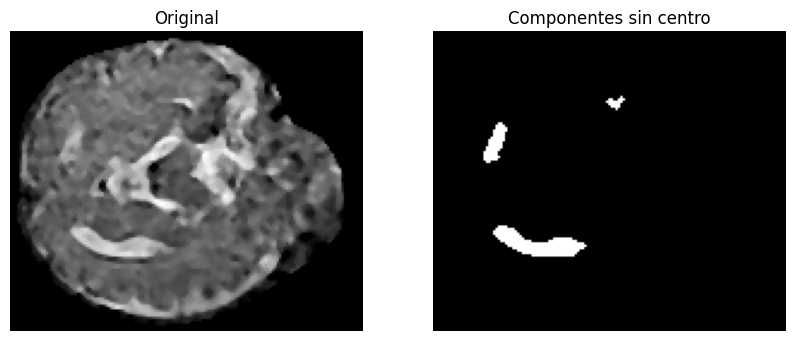

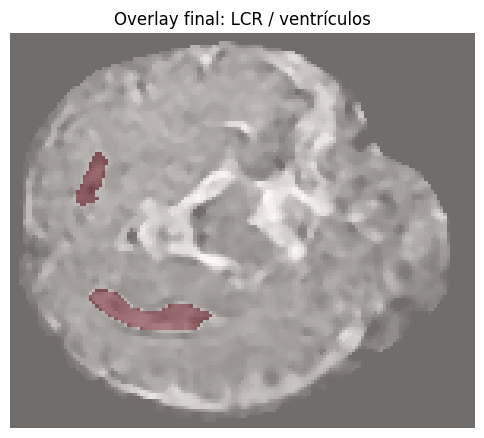


Resultado guardado en resultado_etapa3.npy


In [19]:
# ===========================
# ETAPA 3: Detección de LCR / ventrículos
# ===========================
# Objetivo:
# A partir de la imagen ya preprocesada en Etapa 2, detectar regiones brillantes
# compatibles con LCR y conservar principalmente las regiones correspondientes
# a los ventrículos laterales.

import numpy as np
import matplotlib.pyplot as plt

# Operaciones morfológicas:
# - disk: crea elementos estructurantes circulares.
# - opening: elimina ruido pequeño.
# - closing: cierra huecos o discontinuidades pequeñas.
# - remove_small_objects: elimina objetos demasiado pequeños.
# - binary_erosion: reduce una máscara para identificar regiones internas.
from skimage.morphology import disk, opening, closing, remove_small_objects, binary_erosion

# label separa objetos conectados.
# regionprops permite medir área, centroide y caja delimitadora de cada objeto.
from skimage.measure import label, regionprops

# Otsu calcula un umbral automático basado en el histograma.
from skimage.filters import threshold_otsu

# Rellena huecos internos dentro de máscaras binarias.
from scipy.ndimage import binary_fill_holes


# ===========================
# FUNCIÓN PARA MOSTRAR ORIGINAL + RESULTADO
# ===========================

def mostrar(original, resultado, titulo):
    # Crear una figura con dos imágenes lado a lado.
    plt.figure(figsize=(10,4))

    # Mostrar imagen original o imagen base.
    plt.subplot(1,2,1)
    plt.imshow(original, cmap='gray')
    plt.title("Original")
    plt.axis("off")

    # Mostrar resultado binario o máscara procesada.
    plt.subplot(1,2,2)
    plt.imshow(resultado, cmap='gray')
    plt.title(titulo)
    plt.axis("off")

    plt.show()


# ===========================
# 1. MÁSCARA DEL CEREBRO
# ===========================
# En esta sección se separa el cerebro/feto del fondo de la imagen.
# Esto evita que el algoritmo detecte regiones brillantes fuera del área anatómica.

# Calcular un umbral automático con Otsu sobre la imagen filtrada.
umbral_cerebro = threshold_otsu(A_filt)

# Crear una máscara inicial del cerebro.
# Se usa umbral_cerebro * 0.5 para ser más permisivos y no perder tejido.
mask_cerebro = A_filt > umbral_cerebro * 0.5

# Aplicar cierre morfológico con disco de radio 6.
# Esto une regiones cercanas y cierra pequeños huecos en la máscara cerebral.
mask_cerebro_limpia = closing(mask_cerebro, disk(6))

# Rellenar huecos internos de la máscara cerebral.
mask_cerebro_limpia = binary_fill_holes(mask_cerebro_limpia)

# Eliminar objetos pequeños que no pertenecen al cerebro.
mask_cerebro_limpia = remove_small_objects(mask_cerebro_limpia, min_size=500)

# Mostrar la máscara cerebral obtenida.
mostrar(A_filt, mask_cerebro_limpia, "Máscara del cerebro")


# ===========================
# 2. DETECTAR LCR BRILLANTE
# ===========================
# En MRI, el LCR suele observarse brillante dependiendo de la secuencia.
# Aquí se buscan los píxeles más brillantes dentro de la máscara cerebral.

# Extraer únicamente los píxeles que pertenecen al cerebro.
pixeles_brain = A_filt[mask_cerebro_limpia]

# Calcular el percentil 85 de intensidad dentro del cerebro.
# Los píxeles por encima de este valor se consideran candidatos a LCR.
umbral_lcr = np.percentile(pixeles_brain, 85)

# Crear máscara inicial de LCR:
# - píxeles con intensidad mayor o igual al umbral de LCR
# - dentro de la máscara cerebral
mask_lcr = (A_filt >= umbral_lcr) & mask_cerebro_limpia

# Mostrar detección inicial de regiones brillantes.
mostrar(A_filt, mask_lcr, "LCR inicial")


# ===========================
# 3. LIMPIAR MÁSCARA INICIAL
# ===========================
# En esta sección se reduce ruido y se mejora la continuidad de la máscara.

# Apertura morfológica:
# elimina puntos pequeños aislados que podrían ser ruido.
mask_lcr_limpia = opening(mask_lcr, disk(1))

# Cierre morfológico:
# une pequeñas discontinuidades y suaviza regiones.
mask_lcr_limpia = closing(mask_lcr_limpia, disk(2))

# Eliminar objetos pequeños menores a 20 píxeles.
mask_lcr_limpia = remove_small_objects(mask_lcr_limpia, min_size=20)

# Mostrar la máscara de LCR después de la limpieza.
mostrar(A_filt, mask_lcr_limpia, "LCR limpio")


# ===========================
# 4. FILTRAR COMPONENTES QUE TOCAN LA PERIFERIA
# ===========================
# Muchas regiones brillantes pueden aparecer en el borde del cerebro o cerca del cráneo.
# Esta parte elimina componentes que tocan demasiado la periferia.

# Erosionar la máscara cerebral con un disco de radio 18.
# Esto crea una región más interna del cerebro.
mask_cerebro_interno = binary_erosion(mask_cerebro_limpia, disk(18))

# El borde cerebral se define como:
# máscara cerebral completa - máscara cerebral interna.
# Es decir, la franja periférica eliminada por la erosión.
borde_cerebro = mask_cerebro_limpia & (~mask_cerebro_interno)

# Mostrar qué zona se considera borde cerebral.
mostrar(A_filt, borde_cerebro, "Borde cerebral eliminado")

# Etiquetar todos los objetos conectados en la máscara limpia de LCR.
labels = label(mask_lcr_limpia)

# Crear una máscara vacía donde se guardarán solo los objetos válidos.
mask_final = np.zeros_like(mask_lcr_limpia, dtype=bool)

# Calcular el área total del cerebro.
area_cerebro = np.sum(mask_cerebro_limpia)

# Definir área mínima relativa.
# Cualquier componente menor a 0.1% del área cerebral se considera demasiado pequeño.
area_min = area_cerebro * 0.001

# Analizar cada componente detectada como posible región de LCR.
for region in regionprops(labels):

    # Extraer la máscara binaria de la componente actual.
    objeto = labels == region.label

    # Área de la componente en píxeles.
    area = region.area

    # Calcular qué proporción de la componente toca el borde cerebral.
    # Si toca mucho borde, probablemente no es ventrículo lateral.
    toca_borde = np.sum(objeto & borde_cerebro) / area

    # Obtener caja delimitadora de la componente.
    minr, minc, maxr, maxc = region.bbox

    # Alto y ancho de la componente.
    alto_obj = maxr - minr
    ancho_obj = maxc - minc

    # Relación de forma.
    # Si es muy alargada, probablemente es borde o artefacto.
    relacion = max(alto_obj, ancho_obj) / (min(alto_obj, ancho_obj) + 1e-8)

    # Criterio 1: área suficiente.
    area_valida = area > area_min

    # Criterio 2: no debe tocar demasiado el borde cerebral.
    no_toca_borde = toca_borde < 0.10

    # Criterio 3: la forma no debe ser extremadamente alargada.
    forma_valida = relacion < 12

    # Si cumple los criterios, se conserva.
    if area_valida and no_toca_borde and forma_valida:
        mask_final[objeto] = True


# ===========================
# 4.5 ELIMINAR COMPONENTES QUE TOCAN RADIO CENTRAL AUTOMÁTICO
#     Y CONSERVAR LAS 2 MÁS GRANDES RESTANTES
# ===========================
# Esta parte intenta eliminar estructuras centrales, como el tercer ventrículo,
# y conservar las dos regiones más grandes restantes, esperadas como ventrículos laterales.

# Obtener dimensiones de la máscara.
alto, ancho = mask_final.shape

# Obtener coordenadas de todos los píxeles dentro del cerebro.
coords = np.argwhere(mask_cerebro_limpia)

# Calcular centro aproximado del cerebro.
# cy corresponde al eje vertical y cx al eje horizontal.
cy = np.mean(coords[:, 0])
cx = np.mean(coords[:, 1])

# Calcular área cerebral.
area_cerebro = np.sum(mask_cerebro_limpia)

# Calcular un radio equivalente como si el cerebro fuera un círculo.
# Esto permite adaptar el radio central al tamaño de cada imagen.
radio_equivalente = np.sqrt(area_cerebro / np.pi)

# Definir radio central automático.
# Las componentes que toquen este círculo central serán eliminadas.
radio_central = 0.4 * radio_equivalente

# Crear matrices de coordenadas para calcular distancias al centro.
Y, X = np.ogrid[:alto, :ancho]

# Calcular distancia de cada píxel al centro del cerebro.
dist = np.sqrt((X - cx)**2 + (Y - cy)**2)

# Crear círculo central.
# True = píxeles dentro del radio central.
circulo_central = dist <= radio_central

# Etiquetar componentes conservadas hasta este punto.
labels = label(mask_final)

# Crear máscara vacía para guardar componentes que NO tocan el centro.
mask_sin_centro = np.zeros_like(mask_final, dtype=bool)

# Revisar componente por componente.
for region in regionprops(labels):

    # Máscara de la componente actual.
    objeto = labels == region.label

    # Evaluar si la componente toca el círculo central.
    toca_centro = np.any(objeto & circulo_central)

    # Si no toca el círculo central, se conserva.
    if not toca_centro:
        mask_sin_centro[objeto] = True

# Mostrar el círculo central usado como zona de exclusión.
mostrar(A_filt, circulo_central, "Radio central automático")

# Mostrar las componentes restantes después de eliminar el centro.
mostrar(A_filt, mask_sin_centro, "Componentes sin centro")

# Etiquetar nuevamente las componentes restantes.
labels = label(mask_sin_centro)

# Medir propiedades de esas componentes.
props = regionprops(labels)

# Ordenar componentes por área, de mayor a menor.
props = sorted(props, key=lambda r: r.area, reverse=True)

# Crear máscara vacía para guardar solo los dos ventrículos laterales.
mask_ventriculos = np.zeros_like(mask_final, dtype=bool)

# Conservar las dos componentes más grandes restantes.
for r in props[:2]:
    mask_ventriculos[labels == r.label] = True

# La máscara final queda formada por esas dos componentes.
mask_final = mask_ventriculos


# ===========================
# 5. OVERLAY FINAL
# ===========================
# Mostrar la segmentación final sobre la imagen original filtrada.

plt.figure(figsize=(6,6))

# Imagen anatómica de base.
plt.imshow(A_filt, cmap='gray')

# Máscara final superpuesta en rojo con transparencia.
plt.imshow(mask_final, cmap='Reds', alpha=0.45)

plt.title("Overlay final: LCR / ventrículos")
plt.axis("off")
plt.show()


# ===========================
# 6. GUARDAR RESULTADO
# ===========================
# Guardar la máscara final y datos necesarios para las etapas posteriores.

np.save('resultado_etapa3.npy', {
    'mask_lcr': mask_final,
    'A_filt': A_filt,
    'voxel_size': voxel_size
})

print('\nResultado guardado en resultado_etapa3.npy')


---- ETAPA 4: MEDICIÓN POR COMPONENTE ----
Comp     Área pix     Área mm²     Ancho mm    Orientación
--------------------------------------------------------------
1             251     141.1875       6.7500       vertical
2              92      51.7500       5.2500     horizontal


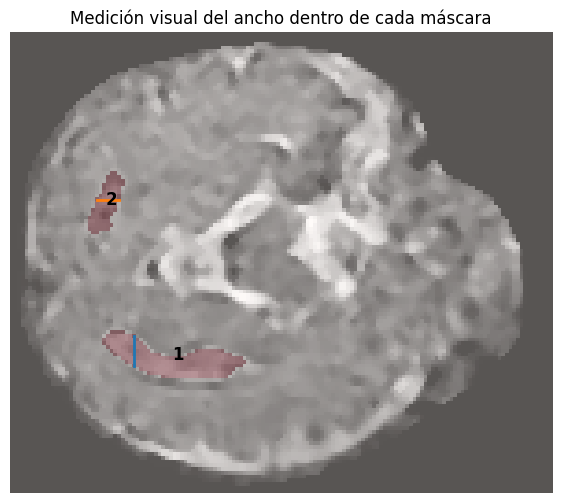


---- RESULTADO FINAL POR VENTRÍCULO ----
Ventrículo       Área mm²  Ancho atrial mm      Clasificación
-----------------------------------------------------------------
1                141.1875           6.7500             Normal
2                 51.7500           5.2500             Normal

Nota: la clasificación se realiza por ventrículo usando el umbral de 10 mm.

Resultado guardado en resultado_etapa4.npy


In [20]:
# ===========================
# ETAPA 4: Medición por componente
# Área separada + ancho atrial dentro de la máscara
# ===========================
# Objetivo:
# Medir cada ventrículo por separado a partir de la máscara segmentada en Etapa 3.
# Para cada componente se calcula:
# - Área en píxeles
# - Área en mm²
# - Ancho atrial en mm
# - Clasificación según umbral de 10 mm

import numpy as np
import matplotlib.pyplot as plt
from skimage.measure import label, regionprops


# ===========================
# 1. CARGAR RESULTADO DE ETAPA 3
# ===========================

# Cargar el archivo generado en Etapa 3.
datos3 = np.load('resultado_etapa3.npy', allow_pickle=True).item()

# Máscara binaria final de los ventrículos.
mask_final = datos3['mask_lcr']

# Imagen filtrada usada como base visual.
A_filt = datos3['A_filt']

# Tamaño del voxel en mm.
voxel_size = datos3['voxel_size']

# Resolución espacial en X y Y.
# Se usa para convertir píxeles a milímetros.
dx = voxel_size[0]
dy = voxel_size[1]


# ===========================
# 2. FUNCIÓN PARA MEDIR ANCHO ATRIAL
# ===========================

def medir_ancho_atrial(mask_objeto, dx, dy):

    # Obtener coordenadas de todos los píxeles que pertenecen a la máscara.
    coords = np.argwhere(mask_objeto)

    # Si la máscara está vacía, no se puede medir.
    if coords.size == 0:
        return 0, None, "sin datos"

    # Buscar la línea horizontal más larga dentro de la máscara.
    mejor_h = 0
    linea_h = None

    for fila in np.unique(coords[:, 0]):

        # Obtener columnas ocupadas en esa fila.
        cols = coords[coords[:, 0] == fila, 1]
        c1, c2 = cols.min(), cols.max()

        # Verificar que toda la línea entre c1 y c2 esté dentro de la máscara.
        if np.all(mask_objeto[fila, c1:c2+1]):
            largo = c2 - c1 + 1

            # Guardar la línea horizontal más larga.
            if largo > mejor_h:
                mejor_h = largo
                linea_h = (c1, fila, c2, fila)

    # Buscar la línea vertical más larga dentro de la máscara.
    mejor_v = 0
    linea_v = None

    for col in np.unique(coords[:, 1]):

        # Obtener filas ocupadas en esa columna.
        filas = coords[coords[:, 1] == col, 0]
        f1, f2 = filas.min(), filas.max()

        # Verificar que toda la línea entre f1 y f2 esté dentro de la máscara.
        if np.all(mask_objeto[f1:f2+1, col]):
            largo = f2 - f1 + 1

            # Guardar la línea vertical más larga.
            if largo > mejor_v:
                mejor_v = largo
                linea_v = (col, f1, col, f2)

    # Convertir longitudes de píxeles a milímetros.
    ancho_h_mm = mejor_h * dx
    ancho_v_mm = mejor_v * dy

    # Se elige la orientación más corta como ancho atrial.
    # Es decir, si el ventrículo es más largo en una dirección,
    # el diámetro clínico se toma sobre el eje menor.
    if ancho_h_mm <= ancho_v_mm:
        return ancho_h_mm, linea_h, "horizontal"
    else:
        return ancho_v_mm, linea_v, "vertical"


# ===========================
# 3. MEDICIÓN POR COMPONENTE
# ===========================

# Etiquetar componentes conectadas.
# Cada componente corresponde idealmente a un ventrículo.
labels = label(mask_final)

# Obtener propiedades geométricas de cada componente.
props = regionprops(labels)

# Ordenar componentes por área, de mayor a menor.
props = sorted(props, key=lambda r: r.area, reverse=True)

print("\n---- ETAPA 4: MEDICIÓN POR COMPONENTE ----")
print(f'{"Comp":<6} {"Área pix":>10} {"Área mm²":>12} {"Ancho mm":>12} {"Orientación":>14}')
print("-"*62)

# Listas para guardar resultados.
areas_mm2 = []
anchos_mm = []

# Mostrar imagen base con máscara superpuesta.
plt.figure(figsize=(7,7))
plt.imshow(A_filt, cmap="gray")
plt.imshow(mask_final, cmap="Reds", alpha=0.35)

# Recorrer cada componente detectada.
for i, region in enumerate(props, start=1):

    # Crear máscara individual de la componente actual.
    objeto = labels == region.label

    # Área en píxeles.
    area_pix = region.area

    # Convertir área a mm².
    area_mm2 = area_pix * dx * dy

    # Medir ancho atrial dentro de la máscara.
    ancho_mm, linea, orientacion = medir_ancho_atrial(objeto, dx, dy)

    # Guardar resultados.
    areas_mm2.append(area_mm2)
    anchos_mm.append(ancho_mm)

    # Obtener centroide para colocar etiqueta visual.
    cy, cx = region.centroid

    # Dibujar línea de medición si existe.
    if linea is not None:
        x1, y1, x2, y2 = linea
        plt.plot([x1, x2], [y1, y2], linewidth=2)

    # Marcar número de componente.
    plt.text(cx, cy, f"{i}", fontsize=12, weight="bold")

    # Imprimir resultados de la componente.
    print(f'{i:<6} {area_pix:>10.0f} {area_mm2:>12.4f} {ancho_mm:>12.4f} {orientacion:>14}')

plt.title("Medición visual del ancho dentro de cada máscara")
plt.axis("off")
plt.show()


# ===========================
# 4. RESULTADO FINAL POR VENTRÍCULO
# ===========================

print("\n---- RESULTADO FINAL POR VENTRÍCULO ----")
print(f'{"Ventrículo":<12} {"Área mm²":>12} {"Ancho atrial mm":>16} {"Clasificación":>18}')
print("-"*65)

clasificaciones = []

# Clasificar cada ventrículo de acuerdo con su ancho atrial.
for i in range(len(areas_mm2)):

    # Si el ancho atrial es ≥ 10 mm, se clasifica como ventriculomegalia.
    if anchos_mm[i] >= 10:
        clasif = "Ventriculomegalia"
    else:
        clasif = "Normal"

    clasificaciones.append(clasif)

    print(f'{i+1:<12} {areas_mm2[i]:>12.4f} {anchos_mm[i]:>16.4f} {clasif:>18}')

print("\nNota: la clasificación se realiza por ventrículo usando el umbral de 10 mm.")


# ===========================
# 5. GUARDAR RESULTADOS
# ===========================

# Guardar resultados para Etapa 5.
# OJO: si filename o img no existen en este notebook, elimina esas dos líneas.
np.save('resultado_etapa4.npy', {
    'areas_mm2': np.array(areas_mm2),
    'anchos_mm': np.array(anchos_mm),
    'mask_final': mask_final,
    'A_filt': A_filt,
    'voxel_size': voxel_size
})

print("\nResultado guardado en resultado_etapa4.npy")